In [1]:
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 
import numpy as np 
import matplotlib.pyplot as plt 


In [2]:
(x_train,_), (_,_) = keras.datasets.mnist.load_data()


x_train = x_train.astype('float32') / 255.0 

x_train = np.reshape(x_train, (-1,28,28,1))

x_train.shape

(60000, 28, 28, 1)

In [3]:
# Build Generator

latent_dim = 100 

generator = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28, 28, 1))
])

generator.summary() 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               12928     
                                                                 
 dense_1 (Dense)             (None, 784)               101136    
                                                                 
 reshape (Reshape)           (None, 28, 28, 1)         0         
                                                                 
Total params: 114,064
Trainable params: 114,064
Non-trainable params: 0
_________________________________________________________________


In [4]:
#build dicriminator
discriminator = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 100,609
Trainable params: 100,609
Non-trainable params: 0
_________________________________________________________________


In [5]:
#Compile discriminator 
discriminator.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
discriminator.trainable = False 

gan_input = keras.Input(shape=(latent_dim,)) 

#generate fake images
fake_image = generator(gan_input) 

#ask discriminator whether fake image is real
gan_output = discriminator(fake_image)

#combine model
gan = keras.Model(gan_input, gan_output)

gan.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    loss='binary_crossentropy'
)

gan.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 100)]             0         
                                                                 
 sequential (Sequential)     (None, 28, 28, 1)         114064    
                                                                 
 sequential_1 (Sequential)   (None, 1)                 100609    
                                                                 
Total params: 214,673
Trainable params: 114,064
Non-trainable params: 100,609
_________________________________________________________________


In [7]:
#Training
batch_size = 128
epochs = 10000 

for epoch in range(epochs):

    #Train Discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    noise = np.random.normal(0,1, (batch_size, latent_dim))
    fake_image = generator.predict(noise, verbose=0) 

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_image, np.zeros((batch_size, 1)))

    #Train Generator
    noise = np.random.normal(0,1, (batch_size,latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1))) 

    if epochs % 1000 == 0:
        print(f"Epoch: {epoch} | "
              f"D_loss: {d_loss_real[0]:.4f} |"
              f"G Loss: {g_loss:.4f}"
        )


Epoch: 0 | D_loss: 1.0288 |G Loss: 1.1387
Epoch: 1 | D_loss: 0.9641 |G Loss: 1.3683
Epoch: 2 | D_loss: 0.9069 |G Loss: 1.6300
Epoch: 3 | D_loss: 0.8218 |G Loss: 1.8822
Epoch: 4 | D_loss: 0.7889 |G Loss: 2.1275
Epoch: 5 | D_loss: 0.7479 |G Loss: 2.3584
Epoch: 6 | D_loss: 0.7259 |G Loss: 2.5518
Epoch: 7 | D_loss: 0.6708 |G Loss: 2.7171
Epoch: 8 | D_loss: 0.6370 |G Loss: 2.8674
Epoch: 9 | D_loss: 0.5932 |G Loss: 2.9479
Epoch: 10 | D_loss: 0.5224 |G Loss: 3.0462
Epoch: 11 | D_loss: 0.4836 |G Loss: 3.1019
Epoch: 12 | D_loss: 0.4483 |G Loss: 3.1506
Epoch: 13 | D_loss: 0.4192 |G Loss: 3.2120
Epoch: 14 | D_loss: 0.3850 |G Loss: 3.2545
Epoch: 15 | D_loss: 0.3398 |G Loss: 3.2506
Epoch: 16 | D_loss: 0.3081 |G Loss: 3.3171
Epoch: 17 | D_loss: 0.2865 |G Loss: 3.2870
Epoch: 18 | D_loss: 0.2723 |G Loss: 3.3386
Epoch: 19 | D_loss: 0.2517 |G Loss: 3.2944
Epoch: 20 | D_loss: 0.2055 |G Loss: 3.3847
Epoch: 21 | D_loss: 0.2033 |G Loss: 3.4176
Epoch: 22 | D_loss: 0.2021 |G Loss: 3.4396
Epoch: 23 | D_loss: 0

In [8]:

#Generate Images

noise = np.random.normal(
    0,
    1,
    (10, latent_dim)
)

generated_images = generator.predict(
    noise,
    verbose=0
)

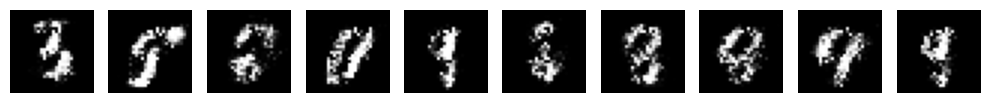

In [9]:
#Display Generated Images

plt.figure(figsize=(10, 2))

for i in range(10):

    plt.subplot(1, 10, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------- VAE Sample 2 -------------------------------

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers, Sequential 

In [22]:
(X_train,_),(_,_) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype('float32')/255.0

In [23]:
X_train[0].shape

(28, 28)

In [24]:
#encoder
latent_dim = 2

encoder_input = keras.Input(shape=(28,28,1))
x = layers.Flatten()(encoder_input)
x = layers.Dense(128, activation='relu')(x)

z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)


In [25]:
encoder = keras.Model(encoder_input,[z_mean,z_log_var], name='encoder')
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 flatten_2 (Flatten)            (None, 784)          0           ['input_4[0][0]']                
                                                                                                  
 dense_4 (Dense)                (None, 128)          100480      ['flatten_2[0][0]']              
                                                                                                  
 z_mean (Dense)                 (None, 2)            258         ['dense_4[0][0]']                
                                                                                            

In [26]:
def Sampling(args):
    z_mean,z_log_var = args 
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    z = z_mean + tf.exp(0.5*z_log_var) * epsilon
    return z 
z = layers.Lambda(Sampling)([z_mean,z_log_var])

In [33]:
#decoder
decoder_input = keras.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='sigmoid')(decoder_input)
x = layers.Dense(28*28, activation='sigmoid')(x)
decoder_output = layers.Reshape((28,28,1))(x)

decoder = keras.Model(decoder_input,decoder_output,name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 2)]               0         
                                                                 
 dense_7 (Dense)             (None, 128)               384       
                                                                 
 dense_8 (Dense)             (None, 784)               101136    
                                                                 
 reshape_2 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
Total params: 101,520
Trainable params: 101,520
Non-trainable params: 0
_________________________________________________________________


In [34]:
outputs = decoder(z)
vae = keras.Model(encoder_input,outputs, name='vae')


In [42]:
reconstruction_loss = keras.losses.binary_crossentropy(encoder_input,outputs)
reconstruction_loss = tf.reduce_sum(reconstruction_loss,axis=(1,2))

In [43]:
kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) + tf.exp(z_log_var),axis=1)
vae.add_loss(reconstruction_loss+kl_loss)

In [44]:
vae.compile(optimizer='adam')

In [45]:
history = vae.fit(X_train,X_train,epochs=10,batch_size=10)

Epoch 1/10


6000/6000 [==============================] - 18s 3ms/step - loss: -120457674752.0000
Epoch 2/10
6000/6000 [==============================] - 16s 3ms/step - loss: -2078179328000.0000
Epoch 3/10
6000/6000 [==============================] - 15s 2ms/step - loss: -9927551614976.0000
Epoch 4/10
6000/6000 [==============================] - 15s 2ms/step - loss: -29396637319168.0000
Epoch 5/10
6000/6000 [==============================] - 15s 2ms/step - loss: -67756988825600.0000
Epoch 6/10
6000/6000 [==============================] - 15s 2ms/step - loss: -133918514741248.0000
Epoch 7/10
6000/6000 [==============================] - 15s 2ms/step - loss: -238185682567168.0000
Epoch 8/10
6000/6000 [==============================] - 15s 3ms/step - loss: -392705670643712.0000
Epoch 9/10
6000/6000 [==============================] - 15s 3ms/step - loss: -611488855228416.0000
Epoch 10/10
6000/6000 [==============================] - 15s 2ms/step - loss: -908032120717312.0000


In [41]:
new_z = np.random.normal(size=(1,latent_dim))
print(new_z)

[[0.08619754 0.45156612]]


In [16]:
new_img = decoder(new_z)

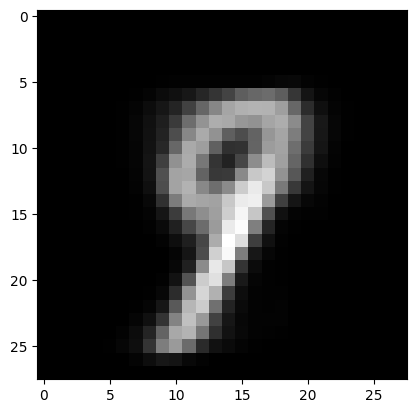

In [18]:
plt.imshow(new_img[0,:,:,0],cmap='gray')
plt.show()

# ------------------------------- GAN Sample 2 -------------------------------

In [55]:
#buld Generator
latent_dim = 100

generator = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28,28,1))
])
generator.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_14 (Dense)            (None, 128)               12928     
                                                                 
 dense_15 (Dense)            (None, 784)               101136    
                                                                 
 reshape_4 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
Total params: 114,064
Trainable params: 114,064
Non-trainable params: 0
_________________________________________________________________


In [56]:
#build descriminator 
discriminator = keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])
discriminator.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_16 (Dense)            (None, 128)               100480    
                                                                 
 dense_17 (Dense)            (None, 32)                4128      
                                                                 
 dense_18 (Dense)            (None, 1)                 33        
                                                                 
Total params: 104,641
Trainable params: 104,641
Non-trainable params: 0
_________________________________________________________________


In [61]:
discriminator.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0002), loss= 'binary_crossentropy',metrics=['accuracy'])

In [62]:
discriminator.trainable = False

gan_input = layers.Input(shape=(latent_dim,))

fake_image = generator(gan_input)

gan_output = discriminator(fake_image)

gan = keras.Model(gan_input,gan_output, name='gan')


In [63]:
gan.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0002), loss= 'binary_crossentropy')

In [64]:
gan.summary()

Model: "gan"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 100)]             0         
                                                                 
 sequential_2 (Sequential)   (None, 28, 28, 1)         114064    
                                                                 
 sequential_3 (Sequential)   (None, 1)                 104641    
                                                                 
Total params: 218,705
Trainable params: 114,064
Non-trainable params: 104,641
_________________________________________________________________


In [ ]:
epochs = 5000
batch_size = 128 

for epoch in range(epochs):
    idx = np.random.randint(0,X_train.shape[0],batch_size)
    real_images = X_train[idx]

    noise = np.random.normal(0,1, (batch_size,latent_dim))
    fake_images = generator.predict(noise, verbose=0) 

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size,1))) 
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((batch_size,1)))

    #train genetator 
    noise = np.random.normal(0,1, (batch_size,latent_dim))
    g_loss = gan.train_on_batch(noise,np.ones((batch_size,1)))

    if epoch%1000 == 0:
        print(
            f"Epoch:{epoch} | "
            f"D Loss:{d_loss_real[0]:.4f} |"
            f"G Loss: {g_loss:.4f} |"
        )


Epoch:0 | D Loss:0.8461 |G Loss: 0.9552 |


KeyboardInterrupt: 